In [ ]:
# IMPORT DATA STORED IN GOOGLE DRIVE

# https://drive.google.com/file/d/1u69UFctzw0K-tJKGsN266eFNMsL0o46v/view?usp=sharing # pco data
!gdown --id 1u69UFctzw0K-tJKGsN266eFNMsL0o46v

# https://drive.google.com/file/d/11QWyy_dQCC7HfWzDoW9YzZexl5Lx4dpy/view?usp=sharing # sp data
!gdown --id 11QWyy_dQCC7HfWzDoW9YzZexl5Lx4dpy

# https://drive.google.com/file/d/1JxzriFYmtZ_U8xfyPS0OZ1_1rrNbZox4/view?usp=sharing # Folder images for labels
!gdown --id 1JxzriFYmtZ_U8xfyPS0OZ1_1rrNbZox4

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1u69UFctzw0K-tJKGsN266eFNMsL0o46v
To: /content/007-20240320-LABCETT-pco.csv
100% 20.5M/20.5M [00:00<00:00, 25.7MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=11QWyy_dQCC7HfWzDoW9YzZexl5Lx4dpy
To: /content/SP_redondo_20240108.csv
100% 50.7k/50.7k [00:00<00:00, 9.44MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Down

In [ ]:
# UNZIM FOTOS FOLDER
!unzip -q fotos_experiencia_radiometro.zip

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:
# EXTRACT FOTOS PATH IDS AND LABELS FOR POSTERIOR DATA PROCESSING

# Define folder path
directory_path = '/content/fotos_experiencia_radiometro'

# List all files in the directory
all_files = os.listdir(directory_path)

# Store labels data (simple list and full tuples list)
listLabels = []
listFullLabels = []
listTupLabels = []

for p in all_files:
  path_split = p.split("_")
  fullLabel_path = path_split[1]
  if fullLabel_path not in listFullLabels:
    #print(fullLabel_path)
    listLabels.append(fullLabel_path.split('-')[0])
    listFullLabels.append(fullLabel_path)


for fl in listFullLabels:
  list_n_path = []
  n = None
  for p in all_files:
    path_full_p = p.split("_")[1]
    path_n = p[-7:-5]
    if path_n != 'kp': # include this because of an error
      if fl == path_full_p and (int(path_n) not in list_n_path):
        #print(fl, path_full_p)
        list_n_path.append(int(path_n))
        n = int(p.split('_')[0])
  listTupLabels.append((list_n_path, n,fl.split('-')[0], fl))
  #print(list_n_path)


# NOTA: una de las imágenes está repetida con n = 17. Cambiar a 18, y hacer el resto con 18, 19, 20 y 21

In [ ]:
# READ TARGET AND SPECTRALON SPECTRAL RESPONDE DATA
data_pco = pd.read_csv('/content/007-20240320-LABCETT-pco.csv')
data_sp = pd.read_csv('/content/SP_redondo_20240108.csv')

In [ ]:
# VISUALIZE PCO DATA
data_pco.head()

,wavelength,007-20240320-LABCETT-00060-0-sp,007-20240320-LABCETT-00061-0-sp,007-20240320-LABCETT-00062-0-sp,007-20240320-LABCETT-00063-0-sp,007-20240320-LABCETT-00064-0-sp,007-20240320-LABCETT-00065-0-sp,007-20240320-LABCETT-00066-0-sp,007-20240320-LABCETT-00067-0-sp,007-20240320-LABCETT-00068-0-sp,...,007-20240320-LABCETT-00510-22-tg,007-20240320-LABCETT-00511-22-tg,007-20240320-LABCETT-00512-22-tg,007-20240320-LABCETT-00513-22-tg,007-20240320-LABCETT-00514-22-tg,007-20240320-LABCETT-00515-22-tg,007-20240320-LABCETT-00516-22-tg,007-20240320-LABCETT-00517-22-tg,007-20240320-LABCETT-00518-22-tg,007-20240320-LABCETT-00519-22-tg
0,350.0,0.000165,0.000156,0.000166,0.000162,0.000158,0.000163,0.000156,0.000161,0.000167,...,-2.418711e-06,-0.000004,2.954276e-06,-2.822006e-06,-5.341907e-06,-3.973249e-06,-7.313246e-06,-4.119135e-06,-2.284510e-06,-0.000010
1,351.0,0.000169,0.000170,0.000177,0.000175,0.000180,0.000183,0.000173,0.000170,0.000174,...,-5.862551e-06,-0.000011,-7.090131e-06,-6.968445e-06,-5.905603e-07,6.967584e-07,-7.353340e-06,-9.956069e-06,4.573367e-07,-0.000004
2,352.0,0.000180,0.000189,0.000185,0.000191,0.000193,0.000195,0.000194,0.000185,0.000188,...,-5.248285e-06,-0.000006,-1.049076e-06,2.766963e-07,-1.239517e-06,1.201348e-06,-2.345645e-06,-3.227757e-07,2.752863e-06,-0.000002
3,353.0,0.000194,0.000203,0.000201,0.000202,0.000204,0.000205,0.000204,0.000203,0.000202,...,-2.558371e-06,-0.000001,9.364246e-07,2.850080e-06,-3.526628e-07,-2.318944e-06,-4.437440e-07,5.698700e-06,1.534745e-06,-0.000003
4,354.0,0.000206,0.000211,0.000226,0.000209,0.000218,0.000219,0.000205,0.000222,0.000211,...,-6.910307e-07,-0.000003,-1.103192e-05,-6.543141e-06,3.234030e-06,-6.658489e-06,-4.833399e-06,-7.194272e-07,-3.728961e-06,-0.000006


In [ ]:
# EXTRACT DATA BY SAMPLE AND CALCULATE MEAN VALUE

df_SpTg = pd.DataFrame()
data = data_pco.values[:, 1:]

block_size = 10

for i in range(0, int(data[:, 1:].shape[1]/(2*10))+1):
  for j, t in enumerate(listTupLabels):
      if i == listTupLabels[j][1]:
        print(i, listTupLabels[j][1])
        start = (i) * 2 * block_size

        sp = data[:, start : start + block_size]
        tg = data[:, start + block_size : start + 2 * block_size]

        sp_mean = sp.mean(axis=1)
        tg_mean = tg.mean(axis=1)

        df_SpTg[f'{t[2]};{t[3]}_sp'] = sp_mean
        df_SpTg[f'{t[2]};{t[3]}_tg'] = tg_mean

        print(listTupLabels[j][3], start, start + block_size, "-", start + block_size, start + 2 * block_size)

0 0
arena 0 10 - 10 20
1 1
arena-1.8g 20 30 - 30 40
2 2
arena-2.8g 40 50 - 50 60
3 3
tierra 60 70 - 70 80
4 4
tierra-4g 80 90 - 90 100
5 5
tierra-10g 100 110 - 110 120
6 6
tierra-70g 120 130 - 130 140
7 7
contenedor 140 150 - 150 160
9 9
agua-5c 180 190 - 190 200
10 10
agua-10c 200 210 - 210 220
11 11
agua-1.1g 220 230 - 230 240
12 12
tierra-veg1-0.00 240 250 - 250 260
13 13
tierra-veg1-0.25 260 270 - 270 280
14 14
tierra-veg1-0.50 280 290 - 290 300
15 15
tierra-veg1-0.75 300 310 - 310 320
16 16
tierra-veg1-1.00 320 330 - 330 340
17 17
tierra-veg2-0.00 340 350 - 350 360
18 18
tierra-veg2-0.25 360 370 - 370 380
19 19
tierra-veg2-0.50 380 390 - 390 400
20 20
tierra-veg2-1.00 400 410 - 410 420
21 21
agua 420 430 - 430 440
22 22
aceite 440 450 - 450 460


In [ ]:
# EXTRACT SPECTRALON REFLECTANCE DATA
wl_vals = data_sp.values[:, 0]
sp_vals = data_sp.values[:, 1]

In [ ]:
# PRINT AND VISUALIZE SAMPELS LABELS
listlLabels_unq = list(set(listLabels))
print(listlLabels_unq)

['tierra', 'aceite', 'arena', 'contenedor', 'checkpoints', 'agua']


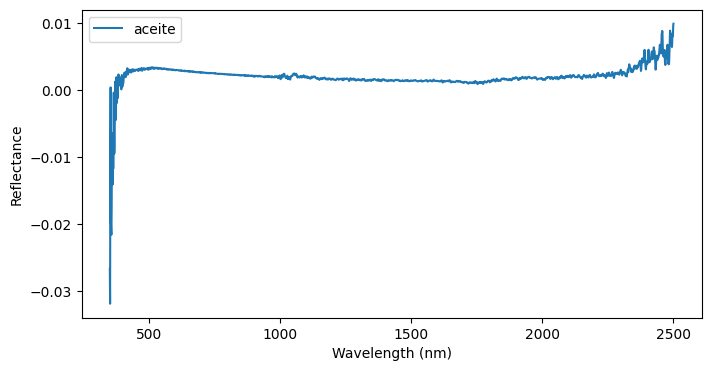

In [ ]:
# VISUALIZE "ACEITE" SAMPLE REFLECTANCE RESPONSE
label_plot = 'aceite'
##-----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

for t in listTupLabels:
  if t[2] == label_test:
    pco_sp = df_SpTg[f'{t[2]};{t[3]}_sp'].values
    pco_tg = df_SpTg[f'{t[2]};{t[3]}_tg'].values

    ref_calc = sp_vals*(pco_tg/pco_sp)

    ax.plot(wl_vals, ref_calc, label=t[3])

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Reflectance')
ax.legend()
plt.show()

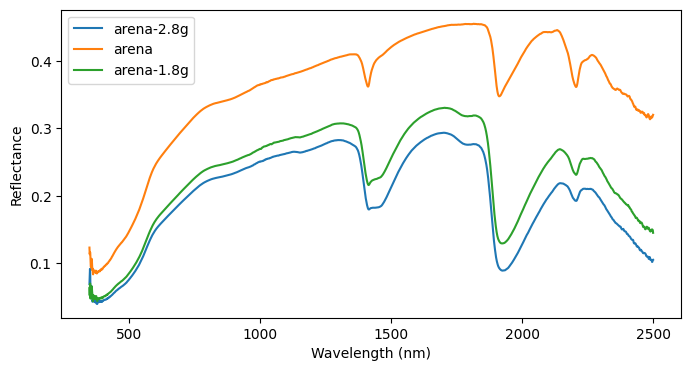

In [ ]:
# VISUALIZE "ARENA" SAMPLE REFLECTANCE RESPONSE
label_plot = 'arena'
##-----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

for t in listTupLabels:
  if t[2] == label_plot:
    pco_sp = df_SpTg[f'{t[2]};{t[3]}_sp'].values
    pco_tg = df_SpTg[f'{t[2]};{t[3]}_tg'].values

    ref_calc = sp_vals*(pco_tg/pco_sp)

    ax.plot(wl_vals, ref_calc, label=t[3])

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Reflectance')
ax.legend()
plt.show()

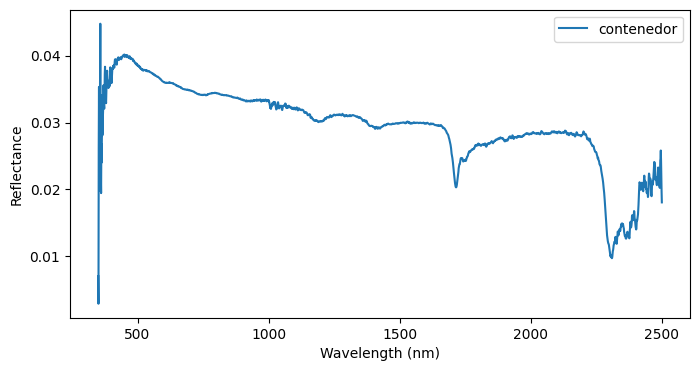

In [ ]:
# VISUALIZE "CONTENEDOR" SAMPLE REFLECTANCE RESPONSE
label_plot = 'contenedor'
##-----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

for t in listTupLabels:
  if t[2] == label_plot:
    pco_sp = df_SpTg[f'{t[2]};{t[3]}_sp'].values
    pco_tg = df_SpTg[f'{t[2]};{t[3]}_tg'].values

    ref_calc = sp_vals*(pco_tg/pco_sp)

    ax.plot(wl_vals, ref_calc, label=t[3])

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Reflectance')
ax.legend()
plt.show()

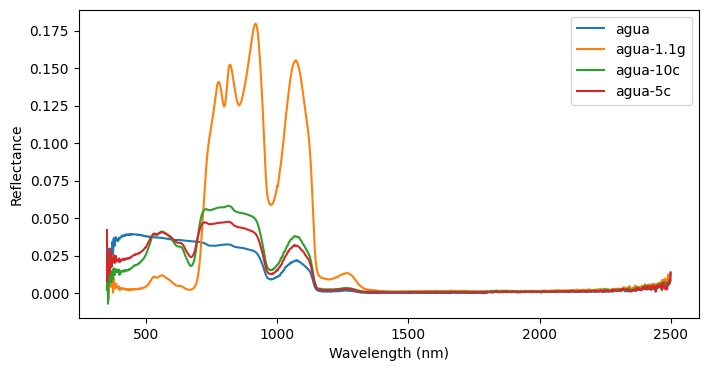

In [ ]:
## VISUALIZE "AGUA" SAMPLE REFLECTANCE RESPONSE
label_plot = 'agua'
##-----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

for t in listTupLabels:
  if t[2] == label_plot:
    pco_sp = df_SpTg[f'{t[2]};{t[3]}_sp'].values
    pco_tg = df_SpTg[f'{t[2]};{t[3]}_tg'].values

    ref_calc = sp_vals*(pco_tg/pco_sp)

    ax.plot(wl_vals, ref_calc, label=t[3])

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Reflectance')
ax.legend()
plt.show()

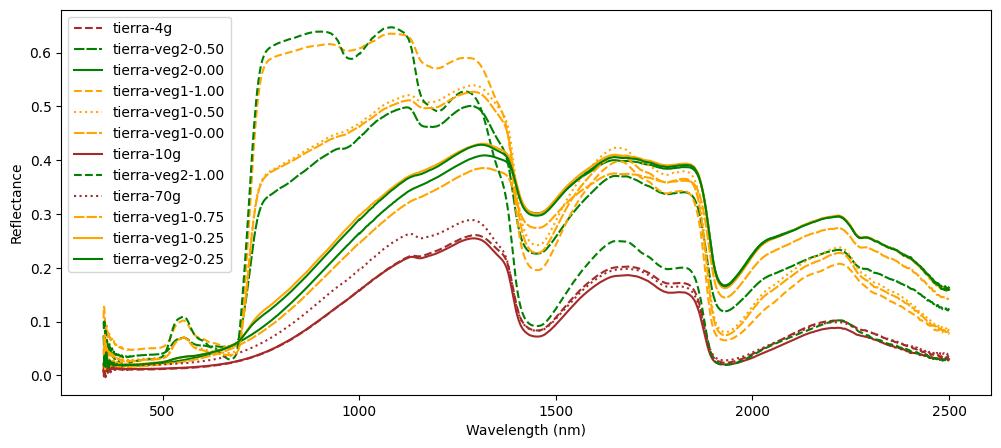

In [ ]:
# VISUALIZE "AGUA" SAMPLE REFLECTANCE RESPONSE
label_plot = 'tierra'
list_subLab = ['veg1', 'veg2']
list_colors = ['orange', 'green', 'brown']

# NEW: styles
line_styles = ['-', '--', ':', '-.', (0, (5, 1))] # (0, (5, 1))custom: long dash, short gap
markers = ['o', 's', '^', 'd', None]

fig, ax = plt.subplots(figsize=(12, 5))

for i, t in enumerate(listTupLabels):
    if t[2] == label_plot:

        pco_sp = df_SpTg[f'{t[2]};{t[3]}_sp'].values
        pco_tg = df_SpTg[f'{t[2]};{t[3]}_tg'].values

        ref_calc = sp_vals * (pco_tg / pco_sp)

        try:
            sublabel = t[3].split('-')[1]

            # Assign color
            if sublabel == list_subLab[0]:
                color = list_colors[0]
            elif sublabel == list_subLab[1]:
                color = list_colors[1]
            else:
                color = list_colors[2]

            # Assign style (cycle through)
            linestyle = line_styles[i % len(line_styles)]
            marker = markers[i % len(markers)]

            ax.plot(
                wl_vals,
                ref_calc,
                label=t[3],
                color=color,
                linestyle=linestyle,
                #marker=marker,
                markevery=60  # show marker every N points (cleaner)
            )

        except:
            pass

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Reflectance')
ax.legend()
plt.show()